# Refund intent detection

**Recipe 02** · Level 1 (Beginner) · Decision type: `Noul`

Judge whether a customer message explicitly requests a refund so Python can flag it for the appropriate workflow.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)

## What you will build

A small refund-intent flag for customer messages. Jev reads one message and answers a single yes/no statement: does this message explicitly ask for a refund? A `Noul` answer is a probability, not a label with its own confidence field, so Python's only lever is a threshold on that probability, chosen on `validation` and then frozen. A message whose probability clears the threshold is queued for the refund workflow to review; everything else needs no further action. By the end you will have looked at individual typed answers, including one the threshold gets wrong on purpose, then an evaluation that reports precision and recall across a sweep of thresholds and the real, non-zero risk the frozen one carries.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    evaluate_selective,
    evaluate_threshold,
    select_threshold,
    threshold_sweep,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_threshold_sweep,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# message that is shown individually and later scored in its split is decided once, so the
# whole notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "refund_requested"
        ]
    return answered[example.id]


run_header(
    2,
    "Refund intent detection",
    backend=backend,
    n_examples=len(scored),
)

Recipe 02: Refund intent detection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `ticket_id` and the message `text`. `build_state` passes on the text only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its ticket.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-explicit"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "ticket_id": "RF3001",
  "text": "The shoes I ordered arrived two sizes too small. I'd like a refund, please."
}
Jev sees:
{
  "text": "The shoes I ordered arrived two sizes too small. I'd like a refund, please."
}


## The questions

There is one proposition, and it asks one thing: does this message explicitly ask for a refund? `Noul` fits because the proposition is either true or false of a given message ([S02](https://docs.typesafe.ai/primitives)). It is written as a statement (`helpers.STATEMENT`), not a question, because CONTRIBUTING.md holds `Noul` propositions to a stricter form than TypeSafe's own documentation shows. "Explicitly" carries the weight of this recipe's hard cases: a plain complaint, a question about refund policy, a request for a replacement or store credit, and a refund mentioned only in passing (a past order, a hypothetical, a future possibility) are all close to this statement without making it true, and the two outcome descriptions below spell that out so the model has something to go on besides the single word "refund".

A `Noul` answer is a single probability, the probability that the statement is true, and nothing else: unlike a `Choice` or a `Score` answer, it has no separate `confidence` field ([S02](https://docs.typesafe.ai/primitives)). That is a deliberate asymmetry in the API, not something this recipe works around: the probability already says everything a yes/no answer can say about itself, and the only design lever left to Python is where to draw the line on it, which is exactly what "Python's part" below does.

In [3]:
proposition = questions["refund_requested"]
print(proposition.instructions)
for name, description in proposition.criteria.items():
    print(f"{name}: {description}")

This message explicitly asks for a refund for the customer's current order.
true: The message asks, right now, for money back on a purchase: using the word refund, asking for a replacement's cost back, or an unmistakable equivalent such as 'give me my money back'. The request can be calm, angry, buried in a longer message, or as short as 'Refund now.'; it is still explicit if a reasonable reader has no doubt the customer wants their money back for this order.
false: The message does not currently ask for money back on this order. This covers a plain complaint with no request attached, a question about refund policy in general, a request for a replacement or store credit instead of a refund, a refund mentioned only in passing (a past order, a hypothetical, a future possibility), and a request to cancel a subscription or return an item without saying the word refund or its equivalent.


## One answer up close

Before any aggregate number, look at three typed answers: a clear refund request, a message that only asks about refund policy, and one where the stored answer and the gold label disagree. Each answer holds just the probability that the statement is true and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

Noul: 0.94 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


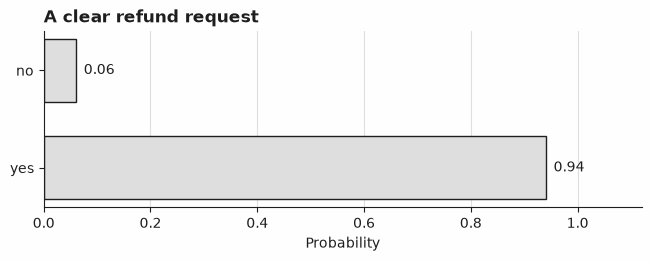

In [4]:
explicit_example = demo["d01-explicit"]
explicit_answer = decide(explicit_example)
show_answer(explicit_answer)
plot_answer_probabilities(explicit_answer, title="A clear refund request")

The shoe-sizing message states outright that the customer wants a refund. The stored answer puts the probability of yes at 0.94, which this recipe's evaluation below will treat as clearing almost any reasonable threshold.

In [5]:
policy_example = demo["d02-policy"]
policy_answer = decide(policy_example)
show_answer(policy_answer)

Noul: 0.25 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


"What's your refund policy if this doesn't work out for me?" asks about the policy, not for a refund on an order the customer has already placed; the gold label for this message is false. The stored probability, 0.25, is low but not negligible, because the word "refund" is still there and a policy question is exactly the near miss this proposition is written to exclude.

In [6]:
hard_example = next(e for e in examples if e.id == "v19-hard-wrong")
hard_answer = decide(hard_example)
print(hard_example.fields["text"])
show_answer(hard_answer)

I thought about asking for a refund, but honestly I'd rather just keep it and have it repaired.
Noul: 0.95 probability of yes (0 is no, 1 is yes)
Provenance: synthetic


"I thought about asking for a refund, but honestly I'd rather just keep it and have it repaired" raises a refund only to set it aside; this recipe's gold label is false. The stored answer calls it 0.95, confidently true. The evaluation below counts this one as wrong, on purpose: a fixture set where every stored answer is right would not teach anything about where a threshold can be fooled. Nothing here says *why* a real model would get this one wrong, because nothing here is a real model: the probability was written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the probability; what happens with it is code. `route` in `helpers.py` flags a message for the refund workflow queue when its probability is at or above a threshold, and leaves it alone otherwise, whatever that probability is: there is no confidence field to layer a second check on top of, so the threshold is the whole rule. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, and on both sides of the threshold, so a rule that quietly always flagged (or never flagged) would fail it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_threshold` sweeps every observed probability as a candidate cut-off and picks the one with the highest `f1` (the harmonic mean of precision and recall, explained below) on the 19 `validation` messages; ties go to the higher, more conservative threshold. Applying that frozen threshold to the three answers shown above, plus one clearly negative message for contrast, shows both outcomes the rule can produce.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_noul = [a.noul for a in val_answers]
threshold = select_threshold(val_gold, val_noul, objective="f1")
print(f"chosen threshold, frozen from here on: {threshold:.2f}{selection}")

negative_example = next(e for e in val_examples if e.id == "v09-complaint")
negative_answer = decide(negative_example)
for shown_example, shown_answer in (
    (explicit_example, explicit_answer),
    (policy_example, policy_answer),
    (hard_example, hard_answer),
    (negative_example, negative_answer),
):
    result = helpers.route(shown_example.fields["ticket_id"], shown_answer, threshold)
    print(f"{result.ticket_id}: noul {shown_answer.noul:.2f} -> {result.outcome} ({result.reason})")

chosen threshold, frozen from here on: 0.80 (a selection step, not a reported result)
RF3001: noul 0.94 -> flagged (noul at or above the threshold: queued for refund review)
RF3002: noul 0.25 -> not_flagged (noul below the threshold: no refund action needed)
RF1019: noul 0.95 -> flagged (noul at or above the threshold: queued for refund review)
RF1009: noul 0.05 -> not_flagged (noul below the threshold: no refund action needed)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.route` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports precision and recall across the full threshold sweep, the same quantities at the frozen threshold on `test`, and the real risk that a flagged message is wrong. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, gold, threshold):
    """Apply route to every answer and tally what it actually did."""
    results = [
        helpers.route(e.fields["ticket_id"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    flagged = [g for r, g in zip(results, gold, strict=True) if r.flagged]
    n_flagged = len(flagged)
    n_right_flagged = sum(flagged)
    n_not_flagged = len(results) - n_flagged
    return results, n_flagged, n_right_flagged, n_not_flagged


val_results, n_flagged, n_right_flagged, n_not_flagged = report(
    val_examples, val_answers, val_gold, threshold
)
print(f"validation, {len(val_examples)} examples{selection}")
print(f"flagged for refund review: {n_flagged} of {len(val_examples)}{selection}")
print(f"right among those flagged: {n_right_flagged} of {n_flagged}{selection}")
print(f"not flagged, no action: {n_not_flagged} of {len(val_examples)}{selection}")

validation, 19 examples (a selection step, not a reported result)
flagged for refund review: 9 of 19 (a selection step, not a reported result)
right among those flagged: 8 of 9 (a selection step, not a reported result)
not flagged, no action: 10 of 19 (a selection step, not a reported result)


`precision` is the fraction of flagged messages that were actually refund requests, and `recall` is the fraction of the real refund requests in this split the rule found at all; `f1` is their harmonic mean, a single number that is low whenever either one is. The chart below sweeps every threshold `select_threshold` considered on `validation`, so the trade-off that produced 0.80 is visible rather than asserted: lower thresholds flag more messages and lose precision; higher ones flag fewer and lose recall.

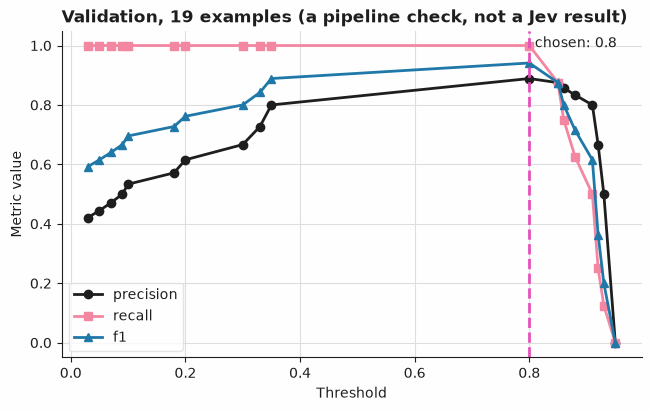

In [9]:
sweep = threshold_sweep(val_gold, val_noul)
plot_threshold_sweep(
    sweep, chosen=threshold, title=f"Validation, {len(val_examples)} examples{check}"
)

`test` is used once, after the threshold is frozen. `evaluate_threshold` reports the same precision, recall and `f1` at exactly that threshold on `test`. `evaluate_selective` reports the same idea in a vocabulary built for exactly this situation, a rule that only acts on some of its inputs: `coverage` is the fraction of `test` messages the threshold flags at all; `accuracy` is the fraction of those flagged messages that are right (the same quantity as `precision`, restated in that vocabulary); and `risk` is its complement, `1 - accuracy`, the fraction of flagged messages that turn out to be wrong despite clearing the bar. Because a flagged message goes to a real queue, `risk` is the number that matters to whoever works it.

In [10]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
test_noul = [a.noul for a in test_answers]

test_results, n_flagged_t, n_right_flagged_t, n_not_flagged_t = report(
    test_examples, test_answers, test_gold, threshold
)
point = evaluate_threshold(test_gold, test_noul, threshold)
print(f"test, {len(test_examples)} examples, threshold {threshold:.2f} frozen{check}")
print(f"flagged for refund review: {n_flagged_t} of {len(test_examples)}{check}")
print(f"right among those flagged: {n_right_flagged_t} of {n_flagged_t}{check}")
print(f"not flagged, no action: {n_not_flagged_t} of {len(test_examples)}{check}")
print(f"precision {point.precision:.3f}  recall {point.recall:.3f}  f1 {point.f1:.3f}{check}")

# The same probability already acts as the decision signal, so it is reused here as the
# "confidence" evaluate_selective expects; the frozen threshold plays both roles (CONTRIBUTING:
# Noul has no separate confidence field).
test_correct = [(n >= threshold) == g for n, g in zip(test_noul, test_gold, strict=True)]
selective = evaluate_selective(test_correct, test_noul, threshold)
print(
    f"coverage {selective.coverage:.3f} "
    f"(flagged {selective.n_answered} of {selective.n_total}){check}"
)
print(f"accuracy among flagged {selective.accuracy:.3f}{check}")
print(f"risk among flagged {selective.risk:.3f}{check}")

test, 19 examples, threshold 0.80 frozen (a pipeline check, not a Jev result)
flagged for refund review: 8 of 19 (a pipeline check, not a Jev result)
right among those flagged: 7 of 8 (a pipeline check, not a Jev result)
not flagged, no action: 11 of 19 (a pipeline check, not a Jev result)
precision 0.875  recall 0.875  f1 0.875 (a pipeline check, not a Jev result)
coverage 0.421 (flagged 8 of 19) (a pipeline check, not a Jev result)
accuracy among flagged 0.875 (a pipeline check, not a Jev result)
risk among flagged 0.125 (a pipeline check, not a Jev result)


The one message `test` gets wrong on the flagged side is `t19-hard-wrong` ("I considered asking for a refund, but I've decided to keep it and just get it repaired instead."), stored at 0.85 and queued even though the gold label is false: that is the risk of 0.125 above, one wrong flag out of eight. The rule also misses one real request, `t06-buried` ("Loved the packaging, by the way, can I get a refund because the item is the wrong size?"), stored at 0.78, just under the 0.80 threshold; that message is not flagged at all, so it does not count against `risk`, but it does lower `recall` to 0.875. Neither number is a guarantee about anything but this fixture set: a threshold chosen for the best `f1` on `validation` is a trade-off measured there, not a promise about `test` or about any message this recipe has not seen -- which is exactly why `validation`'s own flagged-but-wrong count above, 1 of 9, is reported too, rather than only the clean parts of this story.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored messages (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose (including one wrong *and* confident on each split, to show what a frozen threshold does not catch), so every number above describes this fixture set and not a model.

In [11]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard message to `ROWS` in `build_fixtures.py` with the probability you expect a model might give, run `python build_fixtures.py`, and see where `route` sends it.
- Change `select_threshold`'s objective (`"f1"` to `"recall_at_precision"` with a `target`) and see how the flagged count and the risk trade off.
- Neighbouring recipes: [`01-sentiment-classification`](../01-sentiment-classification/) (a `Choice` question with a confidence-based review split) and [`03-response-clarity-scoring`](../03-response-clarity-scoring/) (a `Score` question), the two other decision types `Noul` sits alongside.